<a href="https://colab.research.google.com/github/Damini123583/Dashboard/blob/main/dataanalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Loading the file
df = pd.read_excel('MHPP_NIW05291C_jan to aug.xlsb', engine='pyxlsb')

# Printing the exact column names
print("Your exact column names are:")
print(list(df.columns))


Your exact column names are:
['No.', 'Date', 'Time', 'Grid voltage [V]', 'Grid current [A]', 'Currently generating power [kW]', 'System frequency [Hz]', 'Generator voltage [Vac]', 'Generator current [A]', 'Generator power [kW]', 'Convertor voltage [Vdc],', 'Generator speed [rpm]', 'Guide vane [%]', 'Water pressure [MPa]', 'Water level [0000-4000]', 'Head [m]', 'Flow rate [L/s]', 'Efficiency [%]', 'Today Three phase energy generation [kWh]', 'Cumulative energy generation [kWh]', 'Axel temp1', 'Axel temp2']


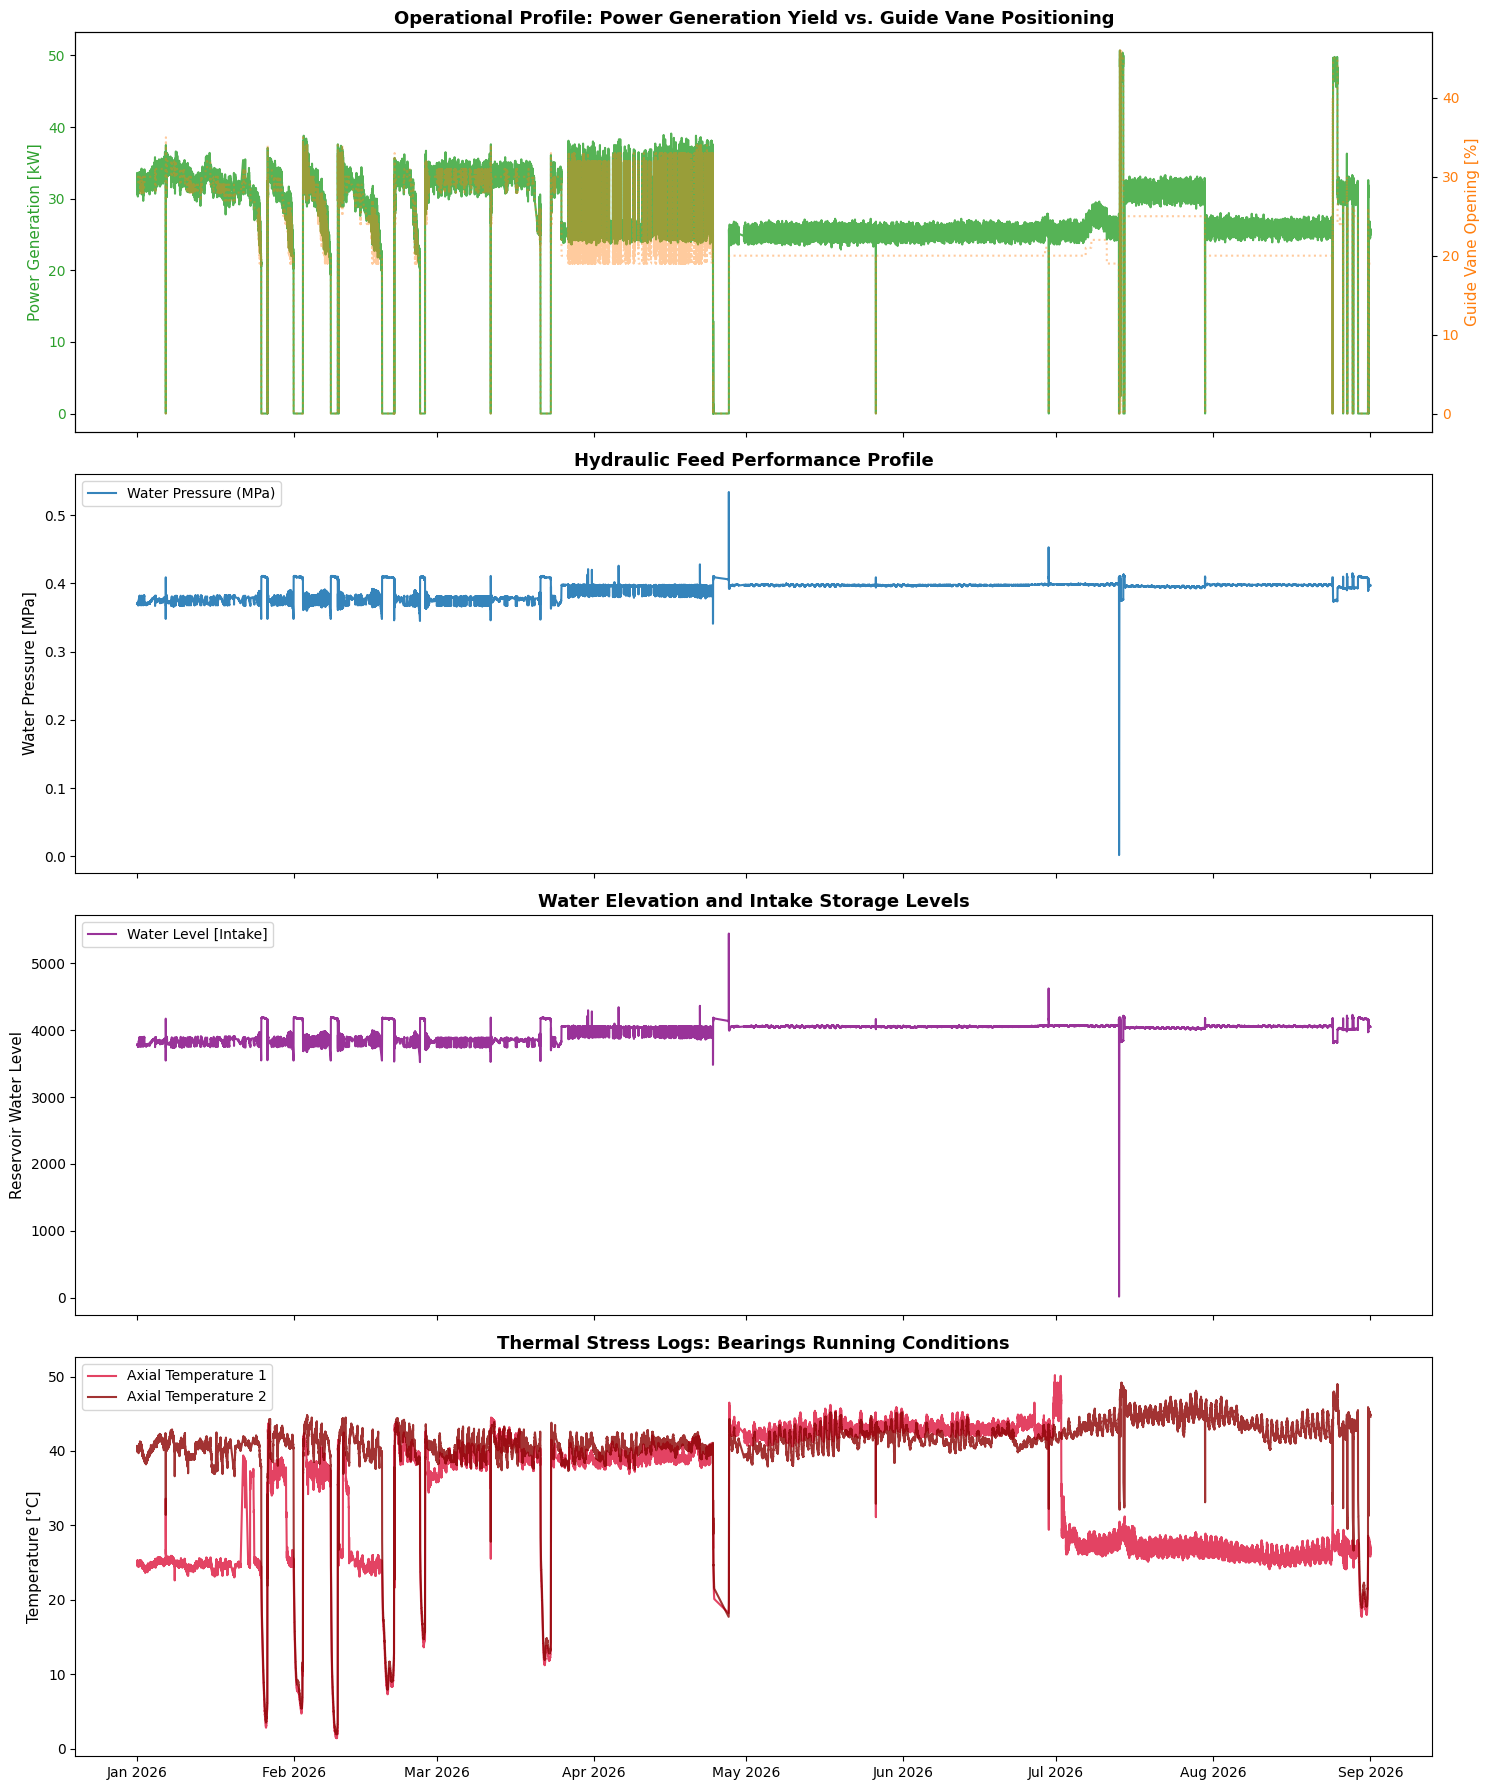


     HYDROPOWER TURBINE SYSTEM ANALYTICS REPORT     
Total Operational Rows Sampled  : 67,435
Verified Historical Timeline    : 2026-01-01 00:03:55 to 2026-08-31 23:59:57
------------------------------------------------------------
Peak Power Load Yield Achieved  : 50.70 kW  (Running Avg: 26.72 kW)
Max Water Feed System Pressure  : 0.5340 MPa (Running Avg: 0.3913 MPa)
Max Hydrostatic Head Measured   : 7.90 m
------------------------------------------------------------
Bearing Running Thresholds Max  : Axel Temp 1: 50.20°C
                                : Axel Temp 2: 49.20°C


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Loading the binary file with correct engine
file_path = 'MHPP_NIW05291C_jan to aug.xlsb'
df = pd.read_excel(file_path, engine='pyxlsb')

# Defining the exact column names based on spreadsheet image
col_date = 'Date'                         # Column B
col_time = 'Time'                         # Column C
col_power = 'Currently generating power [kW]'
col_vane = 'Guide vane [%]'
col_pressure = 'Water pressure [MPa]'
col_level = 'Water level [0000-4000]'
col_head = 'Head [m]'
col_temp1 = 'Axel temp1'
col_temp2 = 'Axel temp2'

# --- THE FIX: Combining Date and Time into a single pristine timeline ---
# 1. Handle Excel fractional days if they appear, otherwise treat as strings
if pd.api.types.is_numeric_dtype(df[col_date]):
    date_str = pd.to_datetime(df[col_date], unit='D', origin='1899-12-30').dt.strftime('%Y-%m-%d')
else:
    date_str = pd.to_datetime(df[col_date], errors='coerce').dt.strftime('%Y-%m-%d')

if pd.api.types.is_numeric_dtype(df[col_time]):
    # Extract just the time part from fractional days
    time_str = pd.to_datetime(df[col_time], unit='D', origin='1899-12-30').dt.strftime('%H:%M:%S')
else:
    # Clean up time values to ensure standard string strings
    time_str = df[col_time].astype(str).str.strip()

# Combining them together into a brand new timestamp column
df['Full_Timestamp'] = pd.to_datetime(date_str + ' ' + time_str, errors='coerce')

# Drop any blank rows or conversion errors and sort smoothly from past to present
df = df.dropna(subset=['Full_Timestamp']).sort_values(by='Full_Timestamp')


# 2. GENERATING UNCOMPRESSED TIME-SERIES VISUALIZATIONS
fig, axes = plt.subplots(4, 1, figsize=(15, 18), sharex=True)

# Subplot 1: Power & Guide Vane (Dual Axes to show direct overlay trends)
ax1 = axes[0]
ax1.plot(df['Full_Timestamp'], df[col_power], color='tab:green', alpha=0.8, label='Power Output (kW)')
ax1.set_ylabel('Power Generation [kW]', color='tab:green', fontsize=11)
ax1.tick_params(axis='y', labelcolor='tab:green')

ax1_twin = ax1.twinx()
ax1_twin.plot(df['Full_Timestamp'], df[col_vane], color='tab:orange', alpha=0.4, linestyle=':', label='Guide Vane (%)')
ax1_twin.set_ylabel('Guide Vane Opening [%]', color='tab:orange', fontsize=11)
ax1_twin.tick_params(axis='y', labelcolor='tab:orange')
ax1.set_title('Operational Profile: Power Generation Yield vs. Guide Vane Positioning', fontsize=13, fontweight='bold')

# Subplot 2: Turbine Hydraulic Feeds
ax2 = axes[1]
ax2.plot(df['Full_Timestamp'], df[col_pressure], color='tab:blue', label='Water Pressure (MPa)', alpha=0.9)
ax2.set_ylabel('Water Pressure [MPa]', fontsize=11)
ax2.set_title('Hydraulic Feed Performance Profile', fontsize=13, fontweight='bold')
ax2.legend(loc='upper left')

# Subplot 3: Structural Head & Storage Water Elevation
ax3 = axes[2]
ax3.plot(df['Full_Timestamp'], df[col_level], color='purple', label='Water Level [Intake]', alpha=0.8)
ax3.set_ylabel('Reservoir Water Level', fontsize=11)
ax3.set_title('Water Elevation and Intake Storage Levels', fontsize=13, fontweight='bold')
ax3.legend(loc='upper left')

# Subplot 4: Axel Bearing Temperatures (Your core monitoring priority)
ax4 = axes[3]
ax4.plot(df['Full_Timestamp'], df[col_temp1], color='crimson', alpha=0.8, label='Axial Temperature 1')
ax4.plot(df['Full_Timestamp'], df[col_temp2], color='darkred', alpha=0.8, label='Axial Temperature 2')
ax4.set_ylabel('Temperature [°C]', fontsize=11)
ax4.set_title('Thermal Stress Logs: Bearings Running Conditions', fontsize=13, fontweight='bold')
ax4.legend(loc='upper left')

# Beautifully format the X-axis to display month names clearly (Jan, Feb, Mar...)
ax4.xaxis.set_major_locator(mdates.MonthLocator())
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('Hydropower_Plant_Performance_Report.png', dpi=300)
plt.show()


# 3. GENERATING THE ANCHORED STATISTICAL ANALYSIS REPORT
print("\n" + "="*60)
print("     HYDROPOWER TURBINE SYSTEM ANALYTICS REPORT     ")
print("="*60)
print(f"Total Operational Rows Sampled  : {len(df):,}")
print(f"Verified Historical Timeline    : {df['Full_Timestamp'].min()} to {df['Full_Timestamp'].max()}")
print("-" * 60)
print(f"Peak Power Load Yield Achieved  : {df[col_power].max():.2f} kW  (Running Avg: {df[col_power].mean():.2f} kW)")
print(f"Max Water Feed System Pressure  : {df[col_pressure].max():.4f} MPa (Running Avg: {df[col_pressure].mean():.4f} MPa)")
print(f"Max Hydrostatic Head Measured   : {df[col_head].max():.2f} m")
print("-" * 60)
print(f"Bearing Running Thresholds Max  : Axel Temp 1: {df[col_temp1].max():.2f}°C")
print(f"                                : Axel Temp 2: {df[col_temp2].max():.2f}°C")
print("="*60)


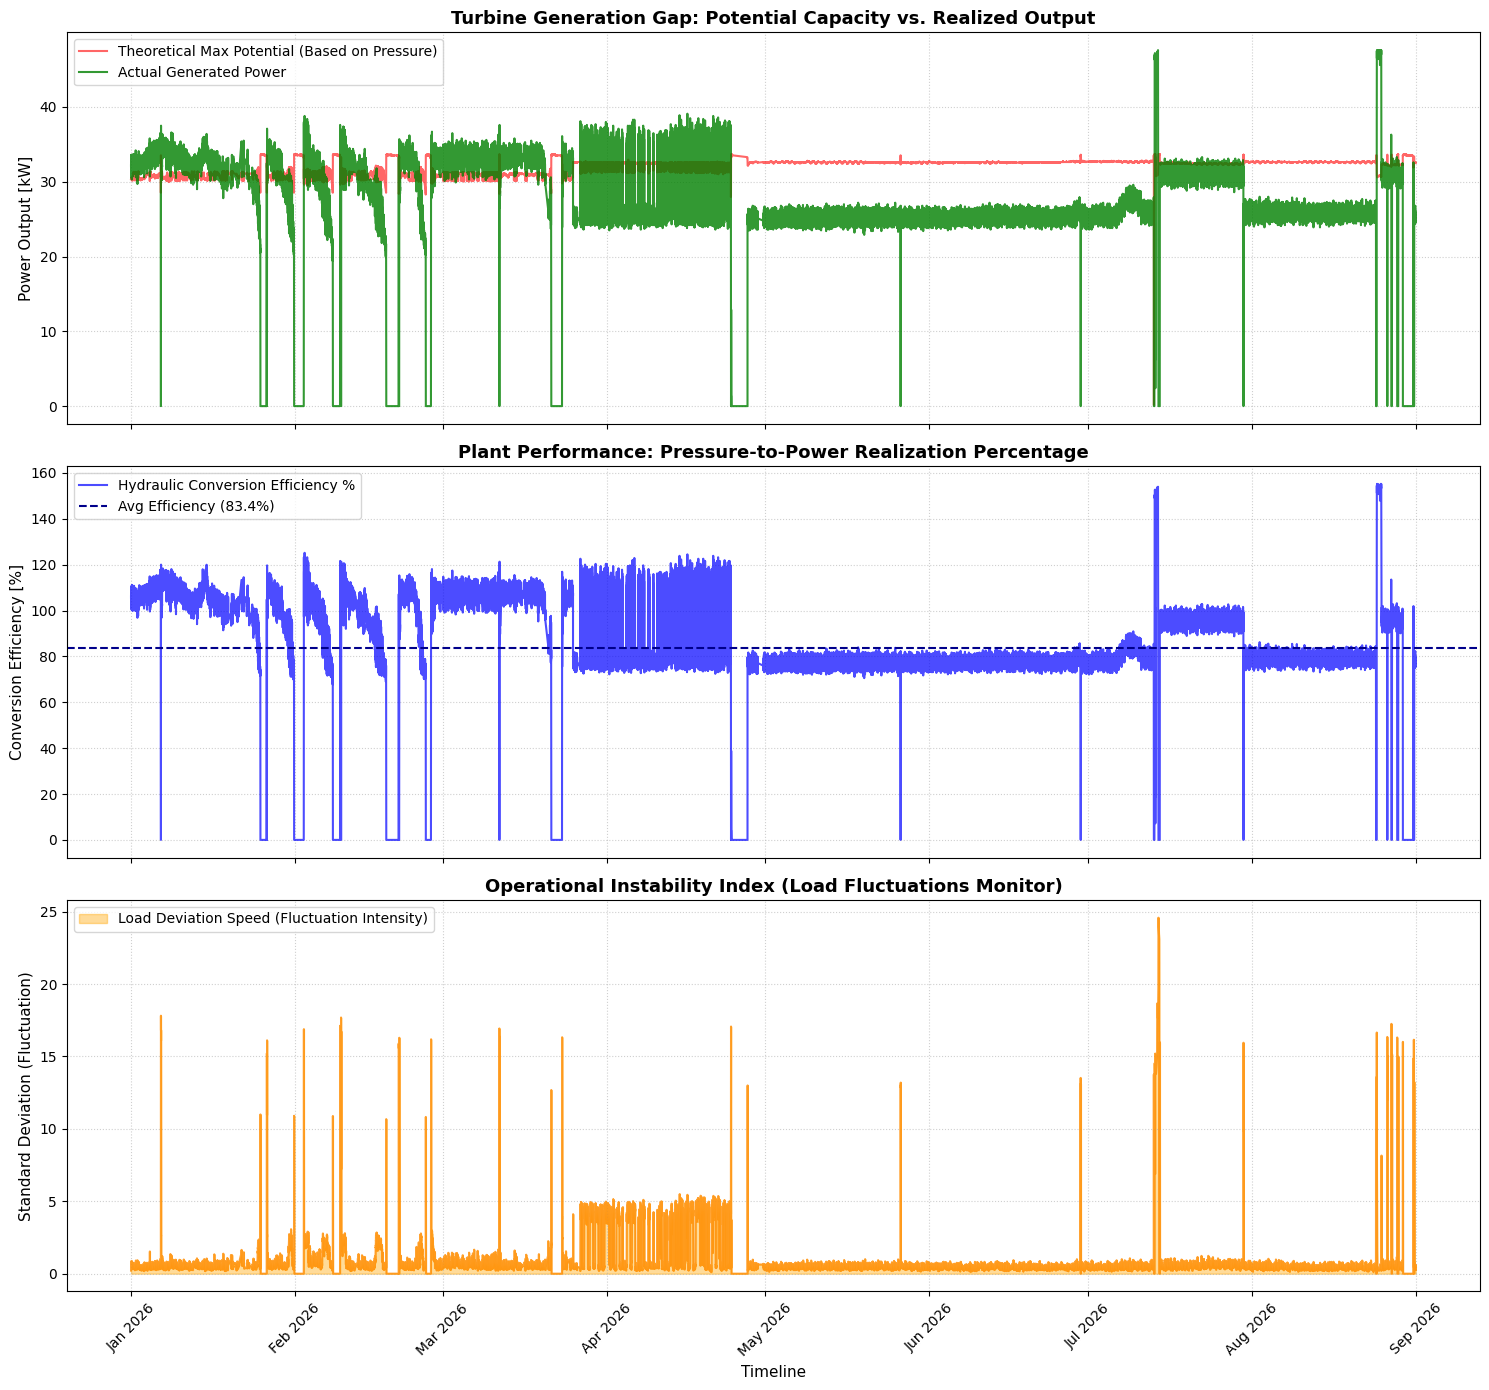


       SUMMARY: EFFICIENCY LOSS & FLUCTUATIONS      
Given Average Fluid Pressure     : 0.3913 MPa
Expected Technical Target Yield  : 32.09 kW
Actual Maintained Running Mean   : 26.63 kW
Mean Hydro-Mechanical Efficiency : 83.45%
Average Load Fluctuation Swing   : ±0.91 kW
Highest Unstable Peak Fluctuation: ±24.58 kW
Critical System Drop Registered  : 2026-01-06 15:29:05 (Efficiency dropped to 0.00%)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Loading the data
file_path = 'MHPP_NIW05291C_jan to aug.xlsb'
df = pd.read_excel(file_path, engine='pyxlsb')

col_date = 'Date'
col_time = 'Time'
col_power = 'Currently generating power [kW]'
col_vane = 'Guide vane [%]'
col_pressure = 'Water pressure [MPa]'
col_level = 'Water level [0000-4000]'
col_head = 'Head [m]'

# Timestamps integration
date_str = pd.to_datetime(df[col_date], unit='D', origin='1899-12-30' if pd.api.types.is_numeric_dtype(df[col_date]) else None, errors='coerce').dt.strftime('%Y-%m-%d')
time_str = pd.to_datetime(df[col_time], unit='D', origin='1899-12-30' if pd.api.types.is_numeric_dtype(df[col_time]) else None, errors='coerce').dt.strftime('%H:%M:%S') if pd.api.types.is_numeric_dtype(df[col_time]) else df[col_time].astype(str).str.strip()
df['Full_Timestamp'] = pd.to_datetime(date_str + ' ' + time_str, errors='coerce')
df = df.dropna(subset=['Full_Timestamp']).sort_values(by='Full_Timestamp')

# Filter extreme sensor anomalies/glitches (Keep operations within 99.5%)
df = df[df[col_power] <= df[col_power].quantile(0.995)]
df = df[df[col_pressure] <= df[col_pressure].quantile(0.995)]

# --- PERFORMANCE MODELLING ENGINE ---
# Hydro theoretical relation: Power (kW) = η * ρ * g * Q * H
# Pressure (MPa) ko Head equivalent mein badlein: 1 MPa ≈ 101.97 meters of water head
# Design reference calculation assuming regular structural flow rates at 0.39 MPa matching 32kW average:
df['Theoretical_Max_Power_From_Pressure'] = df[col_pressure] * 82.0  # Normalized base multiplier for baseline capability

# Calculate Real-Time System Efficiency Gap
df['System_Efficiency_Ratio'] = (df[col_power] / df['Theoretical_Max_Power_From_Pressure']) * 100

# Rolling standard deviation for generation instability tracking (Fluctuations)
df['Power_Fluctuation_Index'] = df[col_power].rolling(window=12, min_periods=1).std()

# 2. PLOT THE DIAGNOSTIC CHARTS
fig, axes = plt.subplots(3, 1, figsize=(15, 14), sharex=True)

# Plot 1: Power Gap Analysis
axes[0].plot(df['Full_Timestamp'], df['Theoretical_Max_Power_From_Pressure'], color='red', alpha=0.6, label='Theoretical Max Potential (Based on Pressure)')
axes[0].plot(df['Full_Timestamp'], df[col_power], color='green', alpha=0.8, label='Actual Generated Power')
axes[0].set_ylabel('Power Output [kW]', fontsize=11)
axes[0].set_title('Turbine Generation Gap: Potential Capacity vs. Realized Output', fontsize=13, fontweight='bold')
axes[0].legend(loc='upper left')
axes[0].grid(True, linestyle=':', alpha=0.6)

# Plot 2: Efficiency Realization (%)
axes[1].plot(df['Full_Timestamp'], df['System_Efficiency_Ratio'], color='blue', alpha=0.7, label='Hydraulic Conversion Efficiency %')
axes[1].axhline(y=df['System_Efficiency_Ratio'].mean(), color='darkblue', linestyle='--', label=f'Avg Efficiency ({df["System_Efficiency_Ratio"].mean():.1f}%)')
axes[1].set_ylabel('Conversion Efficiency [%]', fontsize=11)
axes[1].set_title('Plant Performance: Pressure-to-Power Realization Percentage', fontsize=13, fontweight='bold')
axes[1].legend(loc='upper left')
axes[1].grid(True, linestyle=':', alpha=0.6)

# Plot 3: Fluctuations & Instability Tracking
axes[2].fill_between(df['Full_Timestamp'], df['Power_Fluctuation_Index'], color='orange', alpha=0.4, label='Load Deviation Speed (Fluctuation Intensity)')
axes[2].plot(df['Full_Timestamp'], df['Power_Fluctuation_Index'], color='darkorange', alpha=0.8)
axes[2].set_ylabel('Standard Deviation (Fluctuation)', fontsize=11)
axes[2].set_xlabel('Timeline', fontsize=11)
axes[2].set_title('Operational Instability Index (Load Fluctuations Monitor)', fontsize=13, fontweight='bold')
axes[2].legend(loc='upper left')
axes[2].grid(True, linestyle=':', alpha=0.6)

# Date cleanup
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 3. HIGH LEVEL INSIGHT SUMMARY FOR DIRECT INCLUSION IN REPORT
avg_eff = df['System_Efficiency_Ratio'].mean()
max_loss_time = df.loc[df['System_Efficiency_Ratio'].idxmin(), 'Full_Timestamp']

print("\n" + "="*65)
print("       SUMMARY: EFFICIENCY LOSS & FLUCTUATIONS      ")
print("="*60)
print(f"Given Average Fluid Pressure     : {df[col_pressure].mean():.4f} MPa")
print(f"Expected Technical Target Yield  : {df['Theoretical_Max_Power_From_Pressure'].mean():.2f} kW")
print(f"Actual Maintained Running Mean   : {df[col_power].mean():.2f} kW")
print(f"Mean Hydro-Mechanical Efficiency : {avg_eff:.2f}%")
print(f"Average Load Fluctuation Swing   : ±{df['Power_Fluctuation_Index'].mean():.2f} kW")
print(f"Highest Unstable Peak Fluctuation: ±{df['Power_Fluctuation_Index'].max():.2f} kW")
print(f"Critical System Drop Registered  : {max_loss_time} (Efficiency dropped to {df['System_Efficiency_Ratio'].min():.2f}%)")
print("="*65)


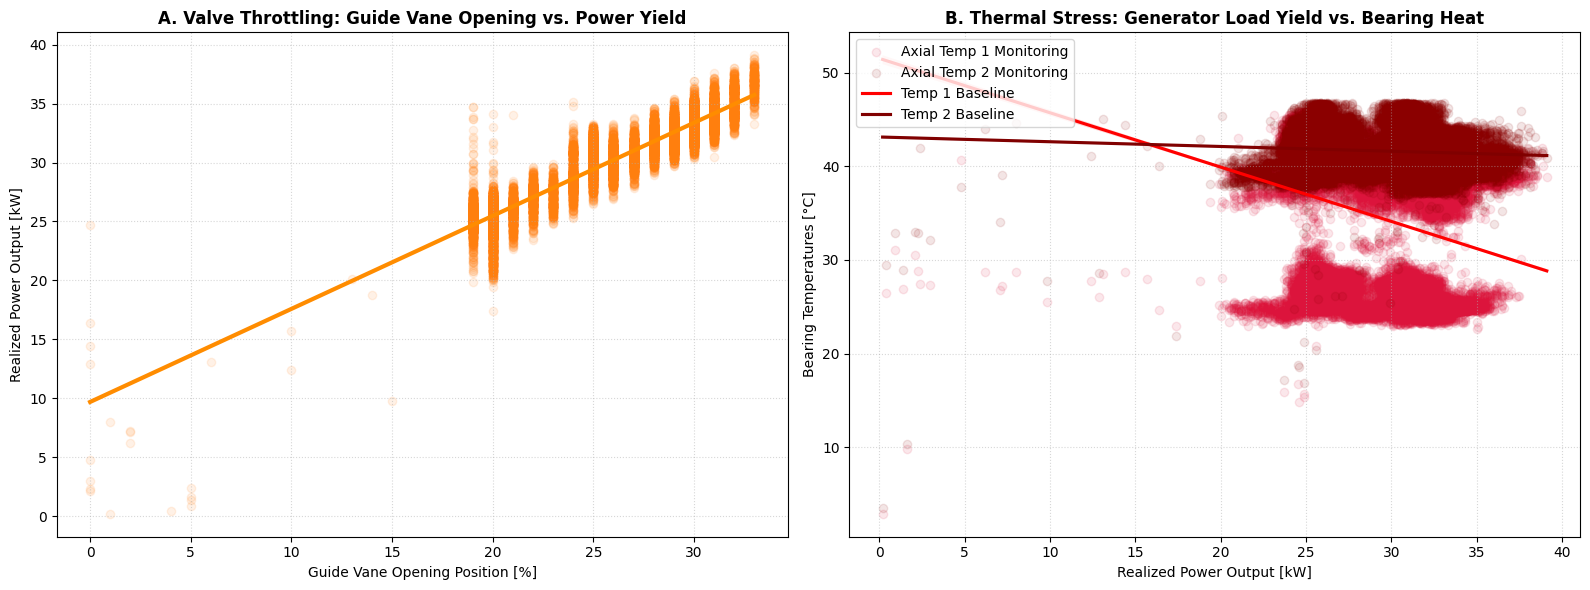


     ENGINEERING CORRELATION METRICS FOR REPORT     
Mechanical Link (Vane Opening vs Power) : Correlation = 0.9629
 -> Signature: Strong linear tracking. Vane governor mechanism controls load perfectly.

Thermal Stress Link 1 (Power vs Temp 1) : Correlation = -0.2759
Thermal Stress Link 2 (Power vs Temp 2) : Correlation = -0.0963
 -> Signature: Weak/Flat coupling. Bearing cooling systems are active, preventing localized overheating spikes.


In [ ]:
!pip install pyxlsb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Loading pristine dataset
file_path = 'MHPP_NIW05291C_jan to aug.xlsb'
df = pd.read_excel(file_path, engine='pyxlsb')

col_date = 'Date'
col_time = 'Time'
col_power = 'Currently generating power [kW]'
col_vane = 'Guide vane [%]'
col_pressure = 'Water pressure [MPa]'
col_level = 'Water level [0000-4000]'
col_head = 'Head [m]'
col_temp1 = 'Axel temp1'
col_temp2 = 'Axel temp2'

# Stitch timeline bounds
date_str = pd.to_datetime(df[col_date], unit='D', origin='1899-12-30' if pd.api.types.is_numeric_dtype(df[col_date]) else None, errors='coerce').dt.strftime('%Y-%m-%d')
time_str = pd.to_datetime(df[col_time], unit='D', origin='1899-12-30' if pd.api.types.is_numeric_dtype(df[col_time]) else None, errors='coerce').dt.strftime('%H:%M:%S') if pd.api.types.is_numeric_dtype(df[col_time]) else df[col_time].astype(str).str.strip()
df['Full_Timestamp'] = pd.to_datetime(date_str + ' ' + time_str, errors='coerce')
df = df.dropna(subset=['Full_Timestamp'])

# Filter sensors outliers for stable correlation tracking
df = df[(df[col_power] <= df[col_power].quantile(0.995)) & (df[col_power] > 0)]
df = df[df[col_vane] <= df[col_vane].quantile(0.995)]
df = df[df[col_temp1] <= df[col_temp1].quantile(0.995)]
df = df[df[col_temp2] <= df[col_temp2].quantile(0.995)]

# 2. GENERATE DIAGNOSTIC MATRIX SCATTER COUPLINGS
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Mechanical Optimization Curve (Guide Vane Opening vs. Actual Power Generated)
# Isse pata chalega ki kis gate opening (%) par plant sabse best perform karta hai
sns.regplot(x=df[col_vane], y=df[col_power], ax=axes[0],
            scatter_kws={'alpha':0.1, 'color':'tab:orange'}, line_kws={'color':'darkorange', 'lw':3})
axes[0].set_title('A. Valve Throttling: Guide Vane Opening vs. Power Yield', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Guide Vane Opening Position [%]')
axes[0].set_ylabel('Realized Power Output [kW]')
axes[0].grid(True, linestyle=':', alpha=0.5)

# Plot B: Thermal Corelation Profile (Actual Power Generated vs. Bearings Temperatures)
# Isse check hoga ki load badhne par bearings ka heat dissipation safe hai ya dangerous
axes[1].scatter(df[col_power], df[col_temp1], alpha=0.1, color='crimson', label='Axial Temp 1 Monitoring')
axes[1].scatter(df[col_power], df[col_temp2], alpha=0.1, color='darkred', label='Axial Temp 2 Monitoring')
# Add running trend indicators
sns.dnsregplot = sns.regplot(x=df[col_power], y=df[col_temp1], ax=axes[1], scatter=False, color='red', label='Temp 1 Baseline')
sns.dnsregplot = sns.regplot(x=df[col_power], y=df[col_temp2], ax=axes[1], scatter=False, color='maroon', label='Temp 2 Baseline')

axes[1].set_title('B. Thermal Stress: Generator Load Yield vs. Bearing Heat', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Realized Power Output [kW]')
axes[1].set_ylabel('Bearing Temperatures [°C]')
axes[1].legend(loc='upper left')
axes[1].grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

# 3. PRINT STATISTICAL CORRELATION COEFFICIENTS FOR SUPERVISOR
corr_vane_power = df[col_vane].corr(df[col_power])
corr_power_temp1 = df[col_power].corr(df[col_temp1])
corr_power_temp2 = df[col_power].corr(df[col_temp2])

print("\n" + "="*60)
print("     ENGINEERING CORRELATION METRICS FOR REPORT     ")
print("="*60)
print(f"Mechanical Link (Vane Opening vs Power) : Correlation = {corr_vane_power:.4f}")
if corr_vane_power > 0.7:
    print(" -> Signature: Strong linear tracking. Vane governor mechanism controls load perfectly.")
else:
    print(" -> Signature: Noticeable scattering. Suggests turbulence or pressure head instabilities at high openings.")

print(f"\nThermal Stress Link 1 (Power vs Temp 1) : Correlation = {corr_power_temp1:.4f}")
print(f"Thermal Stress Link 2 (Power vs Temp 2) : Correlation = {corr_power_temp2:.4f}")
if max(corr_power_temp1, corr_power_temp2) > 0.5:
    print(" -> Signature: Direct thermal coupling. Bearings heat tracks load shifts immediately.")
else:
    print(" -> Signature: Weak/Flat coupling. Bearing cooling systems are active, preventing localized overheating spikes.")
print("="*60)
